# IDX Exchange Data Science

In [60]:
#To do goals
# Load a minimum of 6 months of dataset into pandas.
# • Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.
# • Restrict analysis to PropertyType = Residential and PropertySubType =
# SingleFamilyResidence (per task doc).
# • Deliverable: Jupyter notebook 01_exploration.ipynb with basic EDA plots

In [61]:
#import packages
from pathlib import Path
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Overview
### Loading data

In [62]:
# go through data/ and np.read_csv all 6 files into individual dataframesy
data_dir = Path("data")

# Match files like CRMLSSold202401.csv, CRMLSSOLD_2024-01.csv, etc.
files = sorted(data_dir.glob("CRMLSSold*.csv"))
print(f"Found {len(files)} files")

dfs = {}
for f in files:
    dfs[f.stem] = pd.read_csv(f, low_memory=False)
    print(f"{f.name}: {dfs[f.stem].shape}")

# combining all dataframes into one master dataframe
df_all = pd.concat(
    (pd.read_csv(f, low_memory=False).assign(source_file=f.name) for f in files),
    ignore_index=True
)
print(df_all.shape)

Found 6 files
CRMLSSold202511.csv: (19088, 78)
CRMLSSold202512.csv: (20538, 78)
CRMLSSold202601.csv: (16487, 78)
CRMLSSold202602.csv: (19010, 80)
CRMLSSold202603.csv: (23372, 80)
CRMLSSold202604.csv: (24261, 80)
(122756, 81)


In [63]:
df_all.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122756 entries, 0 to 122755
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 117091 non-null  object 
 1   ListAgentAOR                  122713 non-null  object 
 2   Flooring                      71285 non-null   object 
 3   ViewYN                        110638 non-null  object 
 4   WaterfrontYN                  73 non-null      object 
 5   BasementYN                    1969 non-null    object 
 6   PoolPrivateYN                 109340 non-null  object 
 7   OriginalListPrice             122388 non-null  float64
 8   ListingKey                    122756 non-null  int64  
 9   ListAgentEmail                122453 non-null  object 
 10  CloseDate                     122756 non-null  object 
 11  ClosePrice                    122754 non-null  float64
 12  ListAgentFirstName            122257 non-nul

### Querying data to scope of the project

In [64]:
#Querying to restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc)
df_filtered = df_all.query("PropertyType == 'Residential' and PropertySubType == 'SingleFamilyResidence'")
df_filtered.head(10)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file,OriginatingSystemName,OriginatingSystemSubName
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv,NaN,NaN
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv,NaN,NaN
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv,NaN,NaN
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv,NaN,NaN
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv,NaN,NaN
5,LakeCounty,LakeCounty,Vinyl,True,NaN,NaN,False,325000.0,1147188566,sarahdhomes4sale@gmail.com,...,False,2.0,Konocti Unified,95423,0.0,36590.0,NaN,CRMLSSold202511.csv,NaN,NaN
7,PacificWest,PacificWest,NaN,True,NaN,NaN,True,985000.0,1147186097,kari@thedelaneyteam.com,...,False,2.0,Tustin Unified,92780,0.0,7200.0,NaN,CRMLSSold202511.csv,NaN,NaN
9,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,False,NaN,NaN,False,1700000.0,1147177566,laura@themorenogroupla.com,...,False,NaN,NaN,90025,NaN,7377.0,NaN,CRMLSSold202511.csv,NaN,NaN
11,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000000.0,1147175914,peter@peterheines.com,...,False,3.0,NaN,92064,NaN,NaN,NaN,CRMLSSold202511.csv,NaN,NaN
13,Southland,Southland,NaN,False,NaN,NaN,False,650000.0,1147175754,Simon@MillsRealty.com,...,False,2.0,See Remarks,91354,105.0,21475.0,NaN,CRMLSSold202511.csv,NaN,NaN


In [65]:
# Looking at the description of the filtered dataframe for ClosePrice, LivingArea, Bedrooms, Bathrooms, LotSize
df_filtered.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,6.055400e+04,6.069500e+04,6.069500e+04,60481.000000,60481.000000,60666.000000,6.069500e+04,60695.000000,0.0,0.0,...,0.0,431.000000,0.0,54463.000000,5.964500e+04,37239.000000,58354.000000,43530.000000,5.963900e+04,0.0
mean,1.375642e+06,1.142728e+09,1.320129e+06,34.698478,-118.536124,2049.765625,1.257235e+06,43.304473,NaN,NaN,...,NaN,59.754060,NaN,1.350532,1.913546e+04,2.261634,1.990815,111.650082,5.417351e+05,NaN
std,8.698125e+06,1.342866e+07,7.035355e+06,1.729267,3.581937,1037.058417,1.524326e+06,57.753111,NaN,NaN,...,NaN,240.893723,NaN,0.477141,2.041476e+05,1.418573,2.267713,373.687138,2.264818e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,0.000000,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.250000e+05,1.137048e+09,6.150000e+05,33.754468,-118.987102,1384.000000,6.190000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.357000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.950000e+05,1.146486e+09,8.790000e+05,34.075390,-118.005705,1819.000000,8.790000e+05,21.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.004000e+03,3.000000,2.000000,0.000000,7.253000e+03,NaN
75%,1.399999e+06,1.151802e+09,1.400000e+06,34.673792,-117.249165,2448.000000,1.398000e+06,57.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.820000e+03,3.000000,2.000000,135.000000,1.045400e+04,NaN
max,1.302000e+09,1.159569e+09,7.960000e+08,43.784440,120.432670,31068.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,33.000000,400.000000,20712.000000,1.938943e+09,NaN


## 2. Exploring targe variable `ClosePrice`

In [ ]:
plot_df = df_filtered.copy()
target_column = "ClosePrice"

#converting ClosePrice target variable to numeric, coercing errors to NaN
plot_df[target_column] = pd.to_numeric(
    plot_df[target_column], errors="coerce"
)


feature_columns = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']

print(plot_df.columns.tolist())


['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [83]:
#Checking for target for any null, missing, or non-positive values
print(f"Number of null values in {target_column}: {plot_df[target_column].isnull().sum()}")
print(f"Number of non-positive values in {target_column}: {(plot_df[target_column] <= 0).sum()}")  

#checking description of the target variable ClosePrice
print(f"Description of Target:\n", plot_df[target_column].describe())


Number of null values in ClosePrice: 0
Number of non-positive values in ClosePrice: 0
Description of Target:
 count    6.069500e+04
mean     1.320129e+06
std      7.035355e+06
min      1.750000e+00
25%      6.150000e+05
50%      8.790000e+05
75%      1.400000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64


Text(0.5, 1.0, 'Distribution of ClosePrice (1st to 99th Percentiles)')

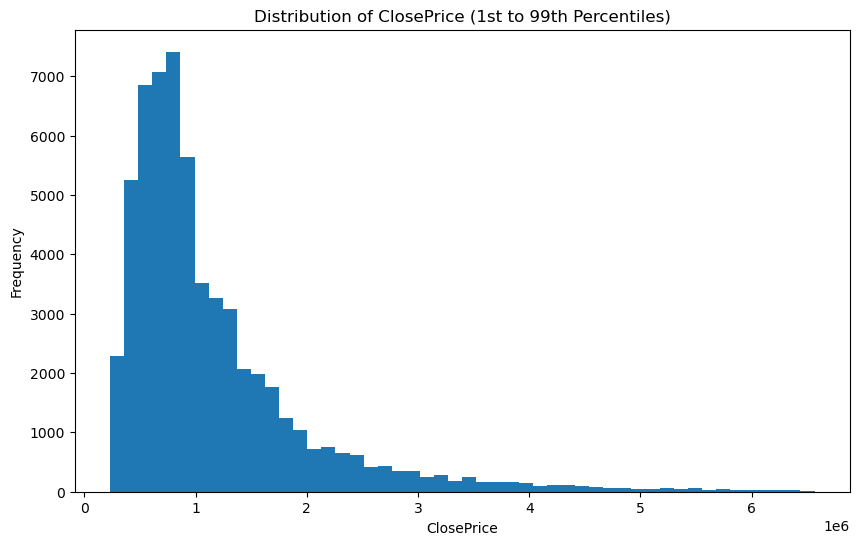

In [88]:
#Graphing the distribution of the target variable ClosePrice using percentiles to limit the x-axis range and avoid extreme outliers
plt.figure(figsize=(10, 6))
# Calculate the 1st and 99th percentiles
lower_bound = plot_df[target_column].quantile(0.01)
upper_bound = plot_df[target_column].quantile(0.99)
plt.hist(plot_df[(plot_df[target_column] >= lower_bound) & (plot_df[target_column] <= upper_bound)][target_column], bins=50)
#adding lables and title
plt.xlabel(target_column)
plt.ylabel("Frequency")
plt.title(f"Distribution of {target_column} (1st to 99th Percentiles)")

The distribution of the target variable ClosePrice is right-skewed, with a long tail on the right side. The majority of the data points are concentrated on the left side of the distribution, indicating that most properties have lower closing prices, while a smaller number of properties have significantly higher closing prices. This skewness suggests that there may be outliers or extreme values in the dataset that could impact statistical analyses and modeling efforts.

Text(0.5, 1.0, 'Log-Transformed Distribution of ClosePrice (1st to 99th Percentiles)')

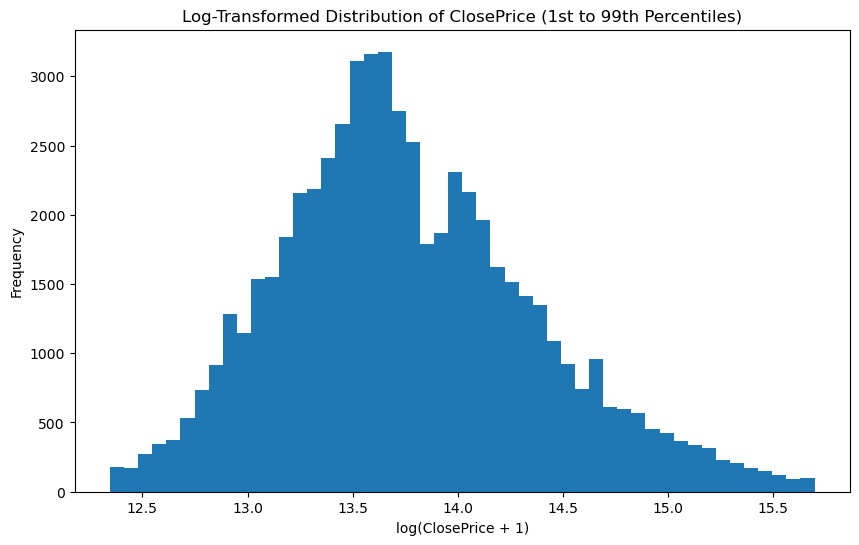

In [89]:
#Apply log transformation to ClosePrice to see if it normalizes the distribution
plt.figure(figsize=(10, 6))
# Apply log transformation, adding 1 to avoid log(0)
log_transformed = np.log1p(plot_df[(plot_df[target_column] >= lower_bound) & (plot_df[target_column] <= upper_bound)][target_column])
plt.hist(log_transformed, bins=50)
plt.xlabel(f"log({target_column} + 1)")
plt.ylabel("Frequency")
plt.title(f"Log-Transformed Distribution of {target_column} (1st to 99th Percentiles)") 

After applying log transformation, we can see that the distribution of ClosePrice is more normalized, which is beneficial for many machine learning algorithms that assume normally distributed data.

### Target scatter plot and distribution

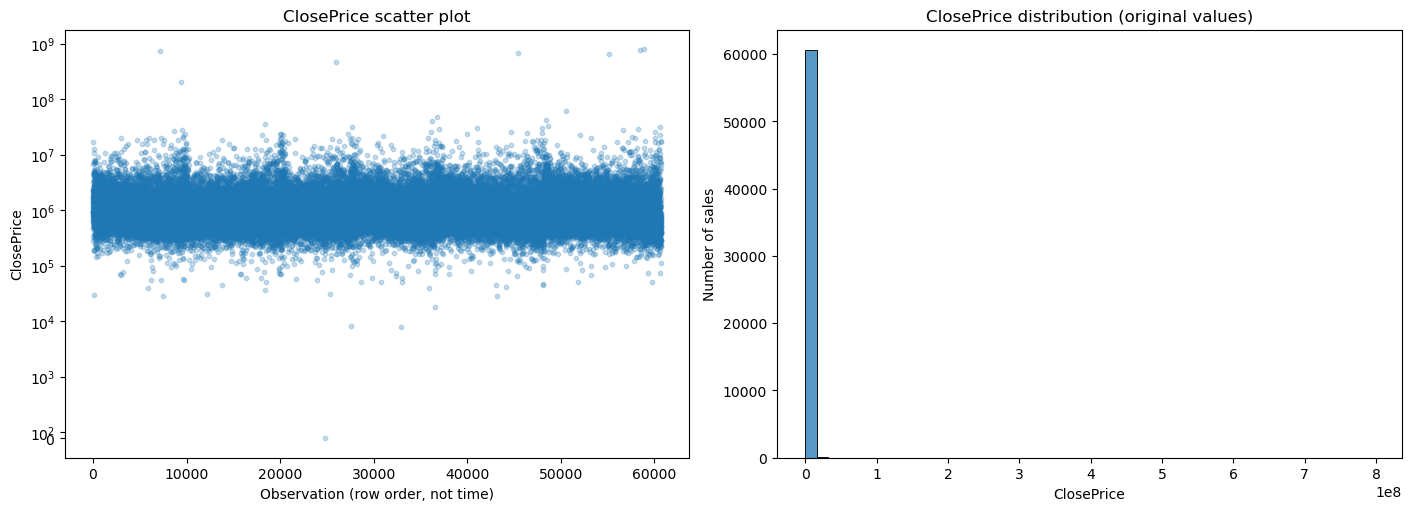

In [90]:
# Scatter shows price spread across rows; histogram shows frequency.
prices = pd.to_numeric(plot_df[target_column], errors="coerce")
prices = prices.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

if prices.empty:
    raise ValueError("The target column has no valid numeric values.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].scatter(prices.index, prices, alpha=0.25, s=10)
axes[0].set(xlabel="Observation (row order, not time)", ylabel=target_column,
            title=f"{target_column} scatter plot")

# This scale preserves zero, negative values, and large outliers.
axes[0].set_yscale("symlog", linthresh=1000)
sns.histplot(prices, bins=50, ax=axes[1])
axes[1].set(xlabel=target_column, ylabel="Number of sales",
            title=f"{target_column} distribution (original values)")
plt.show()

### Numeric predictors versus the target
The scatter plots use a symmetric log price scale to make the spread visible. Correlation does not establish causation. Constant columns or insufficient valid pairs produce missing correlations.

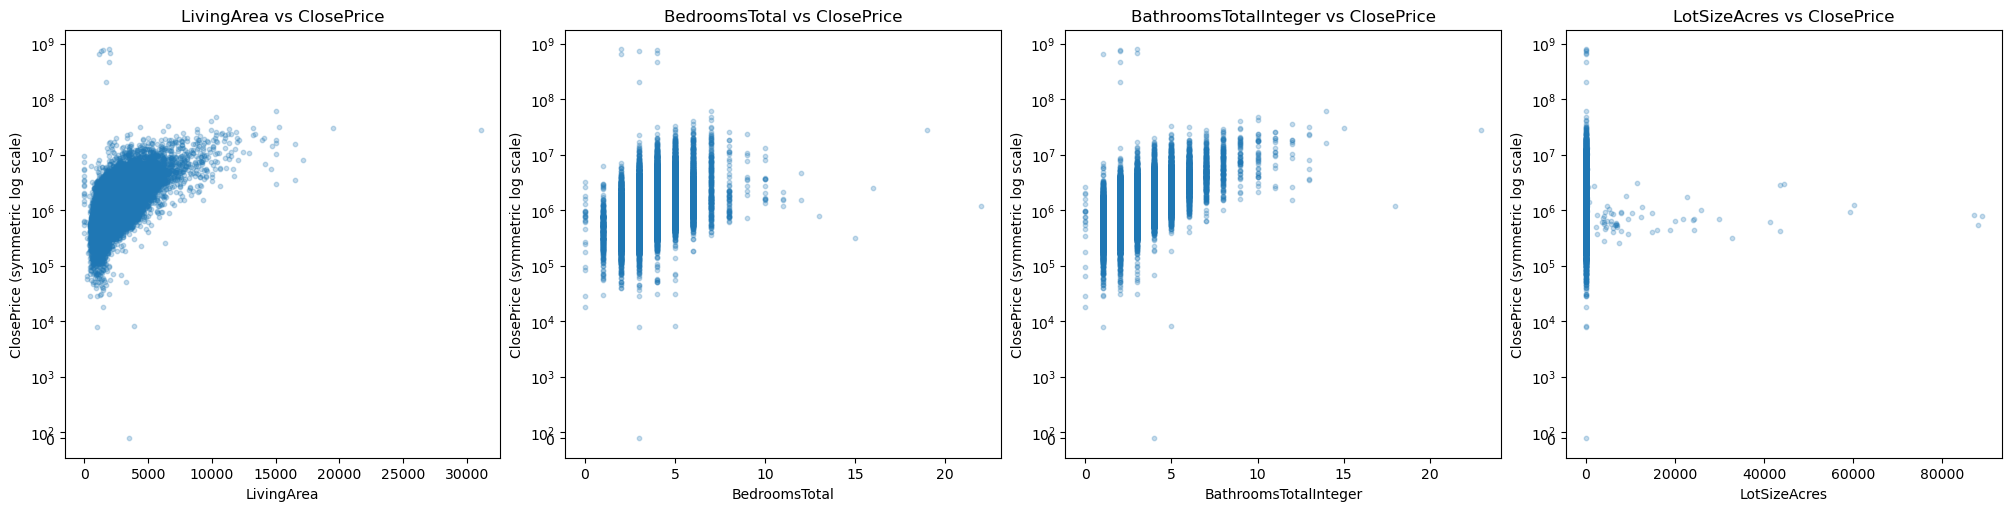

,Pearson,Spearman,Valid pairs
LivingArea,0.121350,0.517246,60666
BedroomsTotal,0.062721,0.370874,60695
BathroomsTotalInteger,0.111603,0.481847,60694
LotSizeAcres,-0.001052,0.098174,59640


In [74]:
columns = [target_column] + feature_columns
missing = [column for column in columns if column not in plot_df.columns]
if missing:
    raise ValueError(f"Replace the placeholder names in feature_columns. Missing columns: {missing}")

plot_data = plot_df[columns].apply(pd.to_numeric, errors="coerce")
plot_data = plot_data.replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(1, len(feature_columns),
figsize= (5 * len(feature_columns), 5),squeeze=False, constrained_layout=True)

for ax, feature in zip(axes.flat, feature_columns):
    pairs = plot_data[[feature, target_column]].dropna()
    ax.scatter(pairs[feature], pairs[target_column], alpha=0.25, s=10)
    ax.set_yscale("symlog", linthresh=1000)
    ax.set(xlabel=feature, ylabel=f"{target_column} (symmetric log scale)",
           title=f"{feature} vs {target_column}")
plt.show()

# Correlations use original numeric values, not the plot's log scale.
# Pearson measures linear relationships; Spearman measures rank relationships.\n",
correlations = pd.DataFrame({
   "Pearson": plot_data.corr(method="pearson")[target_column].drop(target_column),
    "Spearman": plot_data.corr(method="spearman")[target_column].drop(target_column),
    "Valid pairs": [plot_data[[feature, target_column]].dropna().shape[0]for feature in feature_columns],})
display(correlations)

The scatter plots show the relationship between the features and the target variable. The correlations show the strength of the relationship between the features and the target variable. The Pearson correlation measures linear relationships, while the Spearman correlation measures rank relationships. The number of valid pairs shows how many observations were used to calculate the correlations.

The results of the analysis show that LivingArea has the strongest correlation with ClosePrice, followed by BedroomsTotal, BathroomsTotalInteger, and LotSizeAcres. This suggests that larger homes with more bedrooms and bathrooms tend to have higher closing prices. The scatter plots also show that there are some outliers in the data, which may affect the correlations. Further analysis may be needed to investigate these outliers and their impact on the results.

### Distribution of features

Edit `bin_widths` below to control bar widths. Bedrooms and bathrooms use integer-centered bins. Living area and lot size show the 1st–99th percentile range without changing `plot_df`.


In [ ]:
# Feature distributions: choose bin widths separately for each variable.
# Lower these values for narrower bins (more bars).
bin_widths = {
    "LivingArea": 100,              # square feet per bin
    "BedroomsTotal": 1,             # one bin per bedroom count
    "BathroomsTotalInteger": 1,     # one bin per bathroom count
    "LotSizeAcres": 0.05,           # acres per bin
}
count_features = {"BedroomsTotal", "BathroomsTotalInteger"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, feature in zip(axes.flat, bin_widths):
    values = pd.to_numeric(plot_df[feature], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        ax.set_title(f"{feature}: no valid numeric values")
        continue

    width = bin_widths[feature]
    if feature in count_features:
        # Center each bar on an integer, with touching bin boundaries.
        start = np.floor(values.min()) - 0.5
        stop = np.ceil(values.max()) + 0.5
        edges = np.arange(start, stop + width, width)
        shown = values
        subtitle = "all valid values"
    else:
        # Extreme values can stretch the axis and squeeze the main distribution.
        low, high = values.quantile([0.01, 0.99])
        shown = values[values.between(low, high)]
        start = np.floor(low / width) * width
        stop = np.ceil(high / width) * width
        # Avoid creating an enormous number of bars for unusually wide ranges.
        width = max(width, (stop - start) / 200)
        edges = np.arange(start, max(stop, start + width) + width, width)
        subtitle = f"1st–99th percentiles; {len(values) - len(shown):,} values outside range"

    ax.hist(shown, bins=edges, rwidth=1.0, color="steelblue",
            edgecolor="white", linewidth=0.3)
    ax.set(xlabel=feature, ylabel="Number of sales",
           title=f"{feature} (bin width {width:g})\n{subtitle}")
    ax.set_xlim(edges[0], edges[-1])
    ax.margins(x=0)
plt.show()
